## **Messy code for VGAE model, temp, but more efficient**

in respect to `temp.ipynb`, here we do not pass edge_index for each graph, as this operation is very expensive and completely reduntant (we mantain the original GRN structure, modifying just the edge weights: 1 for the edges not affected by the perturbation, 0 for the edges affected by the perturbation).


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd

from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

from torch_geometric.data import Dataset, Data
from torch_geometric.utils import negative_sampling
import os

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

12.1
Tesla V100-SXM2-32GB
cuda


### **Data**

In [4]:
import anndata as ad
import pandas as pd

adata = ad.read_h5ad('../data/vcc_data/adata_Training.h5ad')
adata.raw = adata 
sc.pp.log1p(adata) #data is already log transformed
adata

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'
    uns: 'log1p'

In [5]:
gene_list = pd.read_csv('../data/vcc_data/gene_names.csv', header=None)
gene_list = gene_list[0].tolist()
len(gene_list)

18080

preprocess data so that sitisfy the prerequisites from the VCC
* 18.080 genes
* `target_gene` in `.obs`. This should indicate the gene targeted or `non-targeting` for control cells.
* expression matrix (.X) is of type float32
* Count values in your submission must be either 
    * integers
    * log1p-normalized.

#### **USING GEARS DATASETS:**

In [4]:
from gears import PertData

pert_data = PertData('../data')
pert_data.load(data_name = 'replogle_k562_essential') # norman

Found local copy...
Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
['C7orf26+ctrl' 'C14orf178+ctrl' 'RPS10-NUDT3+ctrl' 'SEM1+ctrl' 'FAU+ctrl']
Local copy of pyg dataset is detected. Loading...
Done!


In [35]:
adata = pert_data.adata
adata

AnnData object with n_obs × n_vars = 162246 × 5000
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

In [36]:
# Rename column and ctrl samples
adata.obs = adata.obs.rename(columns={"condition": "target_gene"})
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)
adata

AnnData object with n_obs × n_vars = 162246 × 5000
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

### **GRN and PyG data preparation**

#### **USING GEARS DATASETS:**

In [37]:
# load GRN
# network file
with open('../SCENIC_GRNs/SCENIC_GRNs/networks/repogle_network.json', 'r') as json_file:
    network = json.load(json_file)
    
# Create the networkx graph
G = nx.DiGraph()
for tf, targets in network.items():
    for target, weight in targets:
        G.add_edge(tf, target, weight=weight)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

Number of nodes: 3390
Number of edges: 11995
Number of node features per node: 1


In [38]:
# filtering data to gene contained in the network G
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.isin(gene_list)]
adata

View of AnnData object with n_obs × n_vars = 162246 × 3390
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

#### **VCC DATASET:**

umm this does not perserve all the genees present in the anndatat file. Let's try by mantaining just the GRNBoost2 random forest graph:

In [14]:
# returns a list of networks (one for each element of data_matrices)
from scipy.stats import spearmanr
from statsmodels.stats.multitest import fdrcorrection
import math
def build_spearman_networks(data_matrix: ad.AnnData, corr_threshold: float):

    # array of pvalues for the correlation of each pair of genes
    gene_names = data_matrix.var_names
    corr, p = spearmanr(data_matrix.X.toarray())
    
    # bonferroni correction
    alpha = 0.05/math.comb(data_matrix.shape[1],2)

    #_, pvals_corrected = fdrcorrection(p, alpha=0.05, method='indep')

    # only significant correlated genes
    coexpression_matrix = ((p<alpha)&(np.absolute(corr)>corr_threshold)).astype(int)
    #np.fill_diagonal(aus, 0)
    cexpression_graph = pd.DataFrame(coexpression_matrix, index=gene_names, columns=gene_names)
    return cexpression_graph

In [7]:
adata_ctrl = adata[adata.obs['target_gene']=='non-targeting']

In [15]:
coexpression_graph = build_spearman_networks(adata_ctrl, 0.1)
coexpression_graph

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
SAMD11,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NOC2L,0,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
KLHL17,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
PLEKHN1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PERM1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
MT-ND4,0,0,0,0,0,0,1,1,0,0,...,1,1,1,1,1,1,1,1,1,1
MT-ND5,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
MT-ND6,0,0,0,0,0,0,0,1,0,0,...,1,1,1,1,1,1,1,1,1,1


In [16]:
# load GRN
network_data = pd.read_csv('../SCENIC_GRNs/SCENIC_GRNs/temp_results/adjacencies.tsv', sep='\t')

# Create the networkx graph
G = nx.DiGraph()
for i in range(network_data.shape[0]):
    edge = network_data.iloc[i,:]
    #if edge['importance']>1.: #TODO: dumb pruning, make somehting better please
    if edge['TF'] in coexpression_graph.columns and edge['target'] in coexpression_graph.columns and coexpression_graph.loc[edge['TF'], edge['target']] == 1:
        if edge['importance']>.5:
            G.add_edge(edge['TF'], edge['target'], weight=edge['importance'])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
#gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

Number of nodes: 12340
Number of edges: 266752
Number of node features per node: 1


In [10]:
import pickle

with open("grn_coexpression_01_vcc_data.pkl", "wb") as file:
    pickle.dump(G, file) 

In [6]:
import pickle

with open("grn_coexpression_01_vcc_data.pkl", "rb") as file:
    G = pickle.load(file)

sigh, still there are some genes that are ot included. I add them to G as isolated nodes.

In [17]:
genes_not_included = [gene for gene in gene_list if gene not in list(G.nodes)] # some genes of gene_list are not included!
G.add_nodes_from(genes_not_included)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
#gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)


Number of nodes: 18080
Number of edges: 266752
Number of node features per node: 1


In [18]:
adata = adata[:, adata.var_names.isin(gene_list)]
adata

View of AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'
    uns: 'log1p'

***

In [19]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [20]:
# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
G = nx.relabel_nodes(G, gene_to_idx)
edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

In [21]:
# HVG 
N = 2000
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=N)
top_hvg_genes = adata[:,adata.var['highly_variable']==True].var_names.tolist()
hvg_indices = [gene_to_idx[gene] for gene in top_hvg_genes]
hvg_mask = torch.zeros(num_nodes, dtype=torch.bool)
hvg_mask[hvg_indices] = True

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:705: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


new, optimized code for this:

In [23]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Create a Custom PyTorch Dataset - use a standard torch Dataset, not a PyG one.
class PerturbationDataset(Dataset):
    def __init__(self, adata, edge_index, gene_to_idx,
                    start_idx=0, end_idx=None):

        self.adata = adata
        self.edge_attr = torch.ones((edge_index.shape[1],1)) #TODO: for now I will not put type
        self.gene_to_idx = gene_to_idx
        self.start_idx = start_idx
        self.end_idx = end_idx
        
        # Pre-compute once
        self.X_data = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
        self.X_data = torch.tensor(self.X_data, dtype=torch.float)
        self.condition = adata.obs['target_gene'] 
        
        # Precompute perturbation map and edge cache
        self.perturb_map = {} # map each perturbation to gene indices
        self.edge_cache = {} # for each perturbation, we store the mask of pertubred edges

        self.num_affected_edges = {}

        for gene_str in self.condition.unique():
            if gene_str == 'non-targeting': 
                continue

            # list of the perturbed genes indices - saved in self.perturb_map
            perturbs = [gene_to_idx[g] for g in gene_str.split('+') if g in gene_to_idx]
            self.perturb_map[gene_str] = torch.tensor(perturbs, dtype=torch.long)

            # true for all the elements of edge_index[1] that are in perturb_map[gene_str]
            mask = torch.isin(edge_index[1], self.perturb_map[gene_str]) 
            self.edge_cache[gene_str] = mask

            self.num_affected_edges[gene_str] = mask.sum().item()

    def __len__(self):
        return self.end_idx - self.start_idx

    def __getitem__(self, idx):
    
        actual_idx = self.start_idx + idx
        cond = self.condition.iloc[actual_idx]
        
        # pert_vector = torch.zeros((self.adata.shape[1],1), dtype = torch.float32)
        # pert_vector[self.perturb_map[cond]] = 1
        pert = self.perturb_map[cond]

        #if cond != 'non-targeting':
        edge_attr = self.edge_attr.clone()
        edge_attr[self.edge_cache[cond]] = -1
        
        # x = pert_vector # node features
        y = self.X_data[actual_idx].view(-1, 1)
        
        return edge_attr, pert, y


pert_adata = adata[adata.obs['target_gene']!='non-targeting']

# ctrl data - this will be an argument of the model class
ctrl_adata = adata[adata.obs['target_gene']=='non-targeting']
ctrl = ctrl_adata.X.toarray() if hasattr(ctrl_adata.X, "toarray") else np.asarray(ctrl_adata.X)
ctrl = torch.tensor(ctrl, dtype=torch.float)
ctrl_gex = ctrl.mean(dim=0, keepdim=True).T.share_memory_()

# Setup
dataset_size = pert_adata.X.shape[0] #80000 or pert_adata.
test_ratio = 0.25
val_ratio = 0.05
test_size = int(dataset_size * test_ratio)
val_size = int(dataset_size * val_ratio)
train_size = dataset_size - test_size - val_size


# Create datasets
train_dataset = PerturbationDataset(
    pert_adata, edge_index, gene_to_idx,
    start_idx=0, 
    end_idx=train_size
)

val_dataset = PerturbationDataset(
    pert_adata, edge_index, gene_to_idx,
    start_idx=train_size, 
    end_idx=train_size+val_size
)

test_dataset = PerturbationDataset(
    pert_adata, edge_index, gene_to_idx,
    start_idx=train_size+val_size, 
    end_idx=dataset_size
)

N_WORKERS = 4 #TODO this will be passed as an argument to tra training load dataset

# Create loaders - graphs are created on-the-fly!
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=N_WORKERS, pin_memory=True) #pin memory optimize transfer to CUDA
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=N_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=N_WORKERS, pin_memory=True)


# Use as normal
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 128169
Test dataset size: 45774
Validation dataset size: 9154


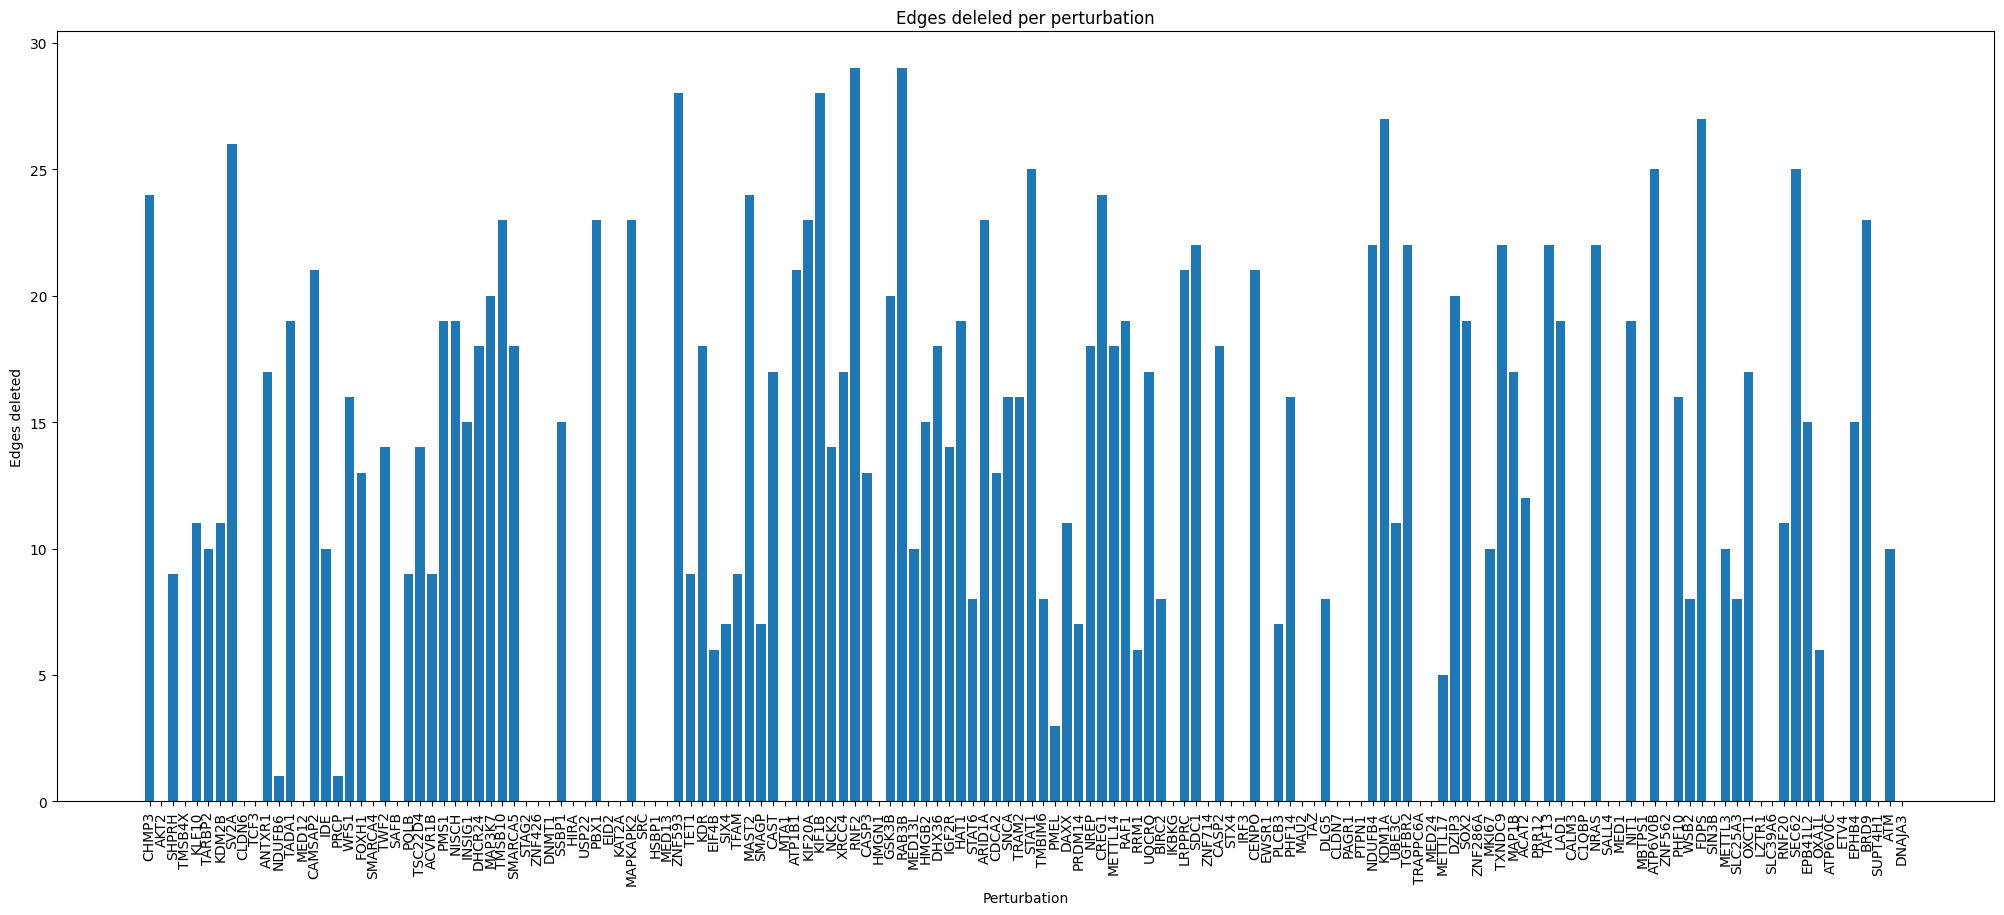

In [12]:
fig, ax = plt.subplots(figsize=(25,10))
ax.bar(list(train_dataset.num_affected_edges.keys()), list(train_dataset.num_affected_edges.values()))
ax.set_xlabel("Perturbation")
ax.set_ylabel("Edges deleted")
ax.set_title("Edges deleled per perturbation")
plt.xticks(rotation=90)
plt.show()

### **Model import and training**

In [24]:
from model_2v_efficient import PerturbModel, train

in_channels, hidden_channels = num_features, 50

model = PerturbModel(in_channels, hidden_channels, edge_index, ctrl_gex, device)
model = model.to(device)
print(model)

PerturbModel(
  (encoder): VariationalGraphEncoder(
    (conv1): ChebConv(1, 50, K=3, normalization=rw)
    (ln1): LayerNorm((50,), eps=1e-05, elementwise_affine=True)
    (conv2): ChebConv(50, 100, K=3, normalization=rw)
    (ln2): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
    (conv_mu): ChebConv(100, 50, K=2, normalization=rw)
    (conv_logstd): ChebConv(100, 50, K=2, normalization=rw)
  )
  (pert_embedding): PerturbEmbed(
    (embedding): Embedding(18080, 50)
  )
  (mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.3, inplace=False)
      (1): Linear(in_features=100, out_features=50, bias=True)
      (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (last_layer): Sequential(
    (0): Linear(in_features=50, out_features=18080, bias=True)
  )
)


In [25]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(num_trainable_params)

1866930


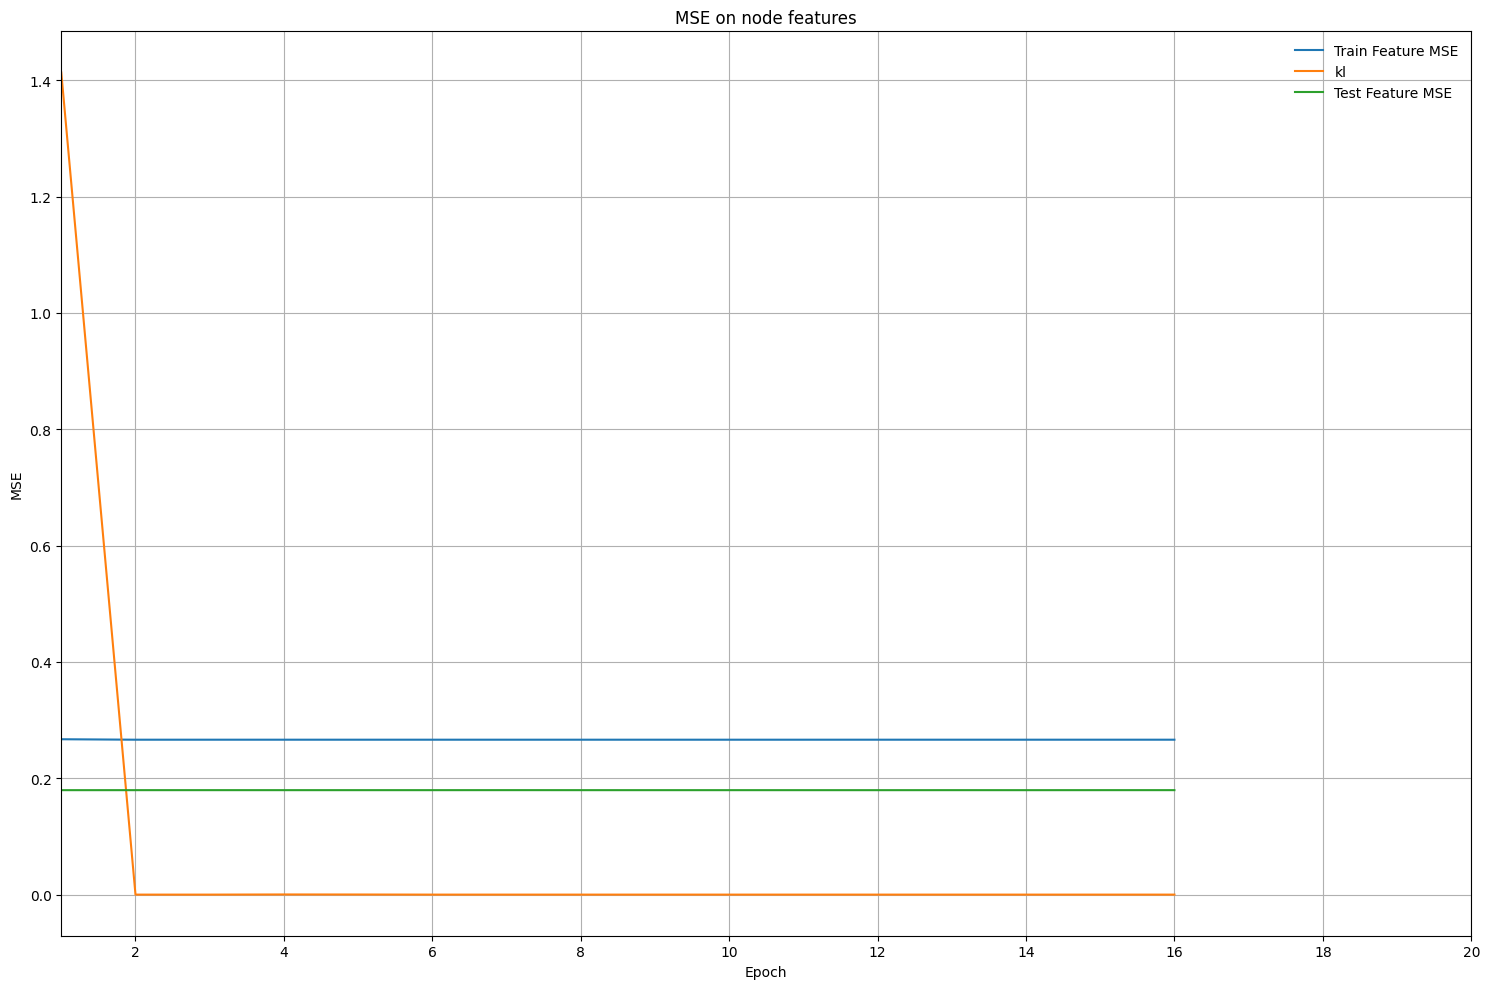

test performances at epoch: 016 | MAE (features): 0.179581


KeyboardInterrupt: 

In [26]:
feat_test_values = train(model=model, 
    train_loader=train_loader, 
    test_loader=val_loader,
    lr=0.003, 
    n_epochs=20, 
    device=device, 
    hvg_mask=hvg_mask,
    live_plot=True)

In [22]:
torch.save(model.state_dict(), "test_20_epochs_EfficientPertModel.pth")

In [13]:
model.load_state_dict(torch.load("complete_20_epochs_dim128_PerturbGraphAE.pth"))

/tmp/ipykernel_1870681/2036563623.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("complete_20_epochs_dim128_PerturbGraphAE.pth"))


<All keys matched successfully>

In [18]:
model.eval()

PerturbModel(
  (encoder): VariationalGraphEncoder(
    (conv1): ChebConv(2, 32, K=3, normalization=sym)
    (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (conv2): ChebConv(32, 64, K=3, normalization=sym)
    (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (conv_mu): ChebConv(64, 32, K=2, normalization=sym)
    (conv_logstd): ChebConv(64, 32, K=2, normalization=sym)
  )
  (mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.3, inplace=False)
      (1): Linear(in_features=32, out_features=32, bias=True)
      (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (last_layer): Sequential(
    (0): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [73]:
from model_2v import test_perturb_model

avg_feat_err = test_perturb_model(model,test_loader, device)
print(f'MAE: {avg_feat_err}')

testing...: 100%|██████████| 513/513 [00:04<00:00, 104.98it/s]

MAE: 0.19788246092043424


In [ ]:
from model import test

avg_auc, avg_ap, avg_feat_err = test(model,test_loader, device)
print(f'AUC: {avg_auc}')
print(f'AP: {avg_ap}')
print(f'MSE: {avg_feat_err}')

***

### **benchmark & VCC**

In [78]:
from baseline import compute_perturbation_mean_baseline_relaxed, evaluate_baseline_mae

# Setup
dataset_size = adata.X.shape[0] #80000
test_ratio = 0.20
val_ratio = 0.10
test_size = int(dataset_size * test_ratio)
val_size = int(dataset_size * val_ratio)
train_size = dataset_size - test_size - val_size

train_adata = adata[:train_size]
train_adata

View of AnnData object with n_obs × n_vars = 62551 × 1207
    obs: 'target_gene', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'

In [79]:
test_adata = adata[(train_size+val_size):dataset_size]
test_adata

View of AnnData object with n_obs × n_vars = 17871 × 1207
    obs: 'target_gene', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'

In [80]:
adata_pred = compute_perturbation_mean_baseline_relaxed(train_adata, test_adata, control_label='non-targeting')

In [83]:
mae_df = evaluate_baseline_mae(adata_pred, test_adata)
mae_df

np.float64(0.19029442703649085)

***

In [ ]:
from visualization import plot_top_highly_expressed_genes
from visualization import plot_top_highly_variable_genes
from visualization import anndata_predict_optimized

In [ ]:
# select genes in the original dataset, maybe just taking the last 1000 cells
n_cells = 5000
n_genes = 20
real_adata = adata[-n_cells:, :]
real_adata

In [ ]:
pred_adata = anndata_predict_optimized(model,real_adata, G, device=device)
pred_adata